In [35]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Gaussian Naive Bayes:Mô hình này được sử dụng chủ yếu trong loại dữ liệu mà các thành phần là các biến liên tục.nó cho rằng các biến sẽ theo một phân phối bình thường?(normal distribution)
Multinomial Naive Bayes:Mô hình này chủ yếu được sử dụng trong phân loại văn bản mà feature vectors được tính bằng Bags of Words. Lúc này, mỗi văn bản được biểu diễn bởi một vector có độ dài d chính là số từ trong từ điển. Giá trị của thành phần thứ i trong mỗi vector chính là số lần từ thứ ixuất hiện trong văn bản đó.
Bernoulli Naive Bayes: Mô hình này được áp dụng cho các loại dữ liệu mà mỗi thành phần là một giá trị binary - bẳng 0 hoặc 1
Thuật toán fast and easy
Thuật toán phổ biến và đươc dùng cho Binary và Multiclass classification
Đặc biệ dùng cho text classification
each feature makes an independent and equal contribution to the outcome
Bới vè các biến độc lập với nhau trong thuật toán này nên không thể học model mà các biến tương quan nhau
Vd: không đề xuất model này cho việc phận loại cancer tissue là harmless hay harmful

Nổi tiếng với phân loại spam mail ..
Phân loại artical về food, clothes...
Sử dụng dataset iris và dùng thuật toán naive baiya

In [36]:
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics
from sklearn.model_selection import train_test_split

In [37]:
df = pd.read_csv(r"C:\Users\ASUS\Downloads\IRIS.csv")

In [38]:
df.head()

,ID,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,1,5.1,3.5,1.4,0.2,setosa
1,2,4.9,3.0,1.4,0.2,setosa
2,3,4.7,3.2,1.3,0.2,setosa
3,4,4.6,3.1,1.5,0.2,setosa
4,5,5.0,3.6,1.4,0.2,setosa


In [39]:
df['Species'].value_counts()

Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

<Axes: xlabel='Sepal.Length', ylabel='Petal.Width'>

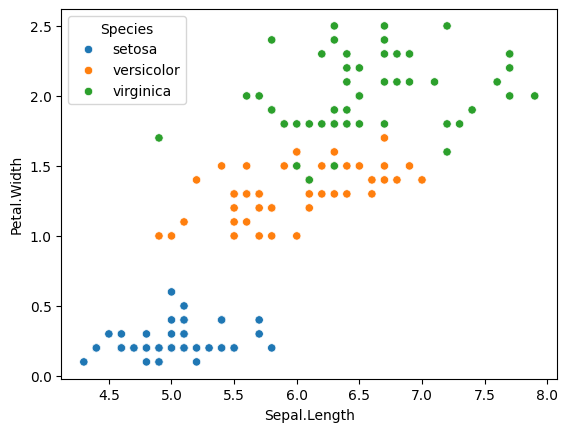

In [40]:
sns.scatterplot(data=df, x='Sepal.Length', y='Petal.Width', hue='Species')

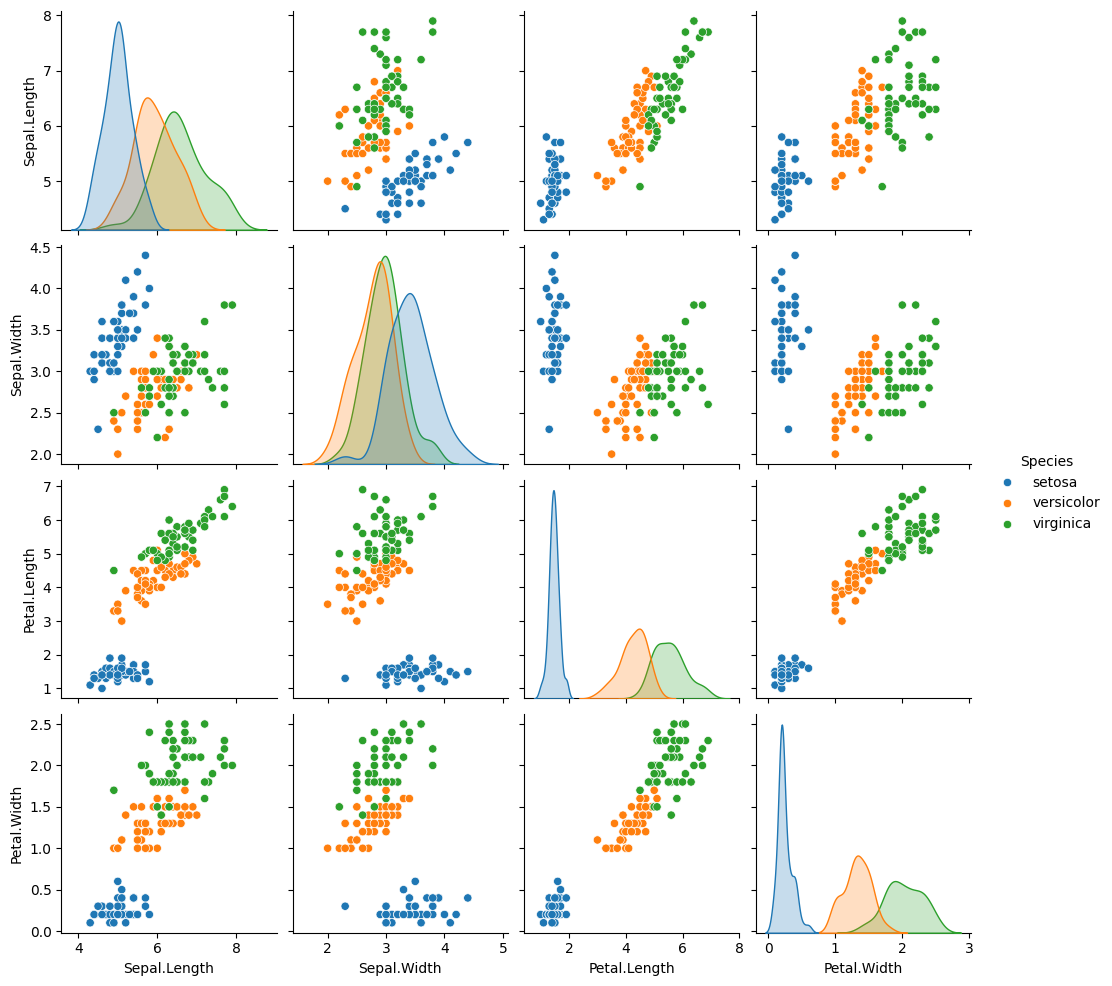

In [27]:
sns.pairplot(df.drop("ID", axis=1), hue="Species")

In [41]:
df['Species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [42]:
mapping = {'setosa':0, 'versicolor':1, 'virginica':2}
df['Species'] = df['Species'].map(mapping)

In [43]:
df['Species'].head(10)

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
Name: Species, dtype: int64

In [45]:
df['Species'].value_counts()

Species
0    50
1    50
2    50
Name: count, dtype: int64

In [46]:
x= df.drop(['ID','Species'],axis=1)
y = df[['Species']]

In [47]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size =0.2,random_state=42)

In [48]:
model = GaussianNB()
model.fit(x_train,y_train)

C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,priors,None
,var_smoothing,1e-09


In [49]:
model.score(x,y)

0.96

In [50]:
expected = y
predicted = model.predict(x)
predicted

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [52]:
print(metrics.classification_report(expected, predicted))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.94      0.94      0.94        50
           2       0.94      0.94      0.94        50

    accuracy                           0.96       150
   macro avg       0.96      0.96      0.96       150
weighted avg       0.96      0.96      0.96       150



In [53]:
print(metrics.confusion_matrix(expected, predicted))

[[50  0  0]
 [ 0 47  3]
 [ 0  3 47]]


In [54]:
ts=[[5.1,3.5,1.4,0.2]]

In [55]:
prediction = model.predict(ts)
print("Dự đoán loại hoa là",prediction)

Dự đoán loại hoa là [0]


C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


Multinomial Naive Baiya

In [57]:
from sklearn.naive_bayes import MultinomialNB


In [59]:
Model1 = MultinomialNB()
Model1.fit(x_train, y_train)

C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [60]:
Model1.score(x,y)

0.94

In [62]:
ex = y
pr = Model1.predict(x)
pr

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 1, 2, 1,
       2, 1, 1, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [63]:
print(metrics.confusion_matrix(ex,pr))

[[50  0  0]
 [ 0 50  0]
 [ 0  9 41]]


In [64]:
print(metrics.classification_report(ex,pr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.85      1.00      0.92        50
           2       1.00      0.82      0.90        50

    accuracy                           0.94       150
   macro avg       0.95      0.94      0.94       150
weighted avg       0.95      0.94      0.94       150



In [ ]:
#accracy 0.94 kém hơn GaussianNB 0.96

bernolli Naive Baiya

In [65]:
from sklearn.naive_bayes import BernoulliNB

In [66]:
Model2 = BernoulliNB()
Model2.fit(x_train, y_train)
Model2.score(x,y)

C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.3333333333333333

In [67]:
ex1 = y
pr1 = Model2.predict(x)

In [68]:
print(metrics.confusion_matrix(ex1,pr1))

[[ 0 50  0]
 [ 0 50  0]
 [ 0 50  0]]


Không dùng BernoulliNB() vì nó trả lời có hỏi yes/no